# Introduction

The aim of this project is to price the European and Binary options using the risk neutral discounted expected payoff formula, and compare results derived from Monte Carlo (Euler Maruyama and Milstein’s framework) against the closed-form Black Scholes framework benchmark. </br></br>

Before diving into the numeric process, it is worth noting there are key differences between the European and binary options, which will impact the interpretation of the estimated options price and the implications in understanding the numbers of simulation required. As same framework can be applicable in both call and put option scenarios, as an illustrative example, this assignment will be responded using European call options. </br></br>

Simple definitions to align on understsanding before going into methodology and calculation details: </br>

**European Call option** – gives right to buy the underlying stock at strike price on expiry date. The pay-off is defined as:

$$
\max(S_T - K, 0)
$$

where $S_T$ = price of the stock at expiry, $K$ = strike price associated with the option.

**Binary Call option** – gives right to receive a fixed payoff at expiry if stock is above strike price. The pay-off is defined as:

$$
\mathbf{1}\{ S_T > K \}
$$

where $S_T$ = price of the stock at expiry, $K$ = strike price associated with the option.

The pay-off structure under European call option implies value of the payoff will be a linear increase above strike price, in the scenario for Binary call option, pay-off is capped at an all-or-nothing amount.

The risk-neutral valuation formula will be used to identify possible payoffs from the option price at expiry, determine the expected payoff assuming risk-free rate exists and discount expected payoff value back to today’s value. The mathematical formula:

$$
V(S,t) = e^{-r(T-t)} \, \mathbb{E}^Q[\text{Payoff}]
$$

Where:  
- $V(S,t)$ = the value of the option today given stock price $S$ and at time $t$  
- $e^{-r(T-t)}$ = the discount factor  
- $\mathbb{E}^Q[\text{Payoff}]$ = the expected payoff value under a risk neutral environment  
</br>
will be used throughout the calculations whether under Euler-Maruyama scheme, Milstein scheme or closed form solution. Along with simulations, there will be insights into option values across each framework (closed-form analytical solution vs discrete approximations of the continuous stochastic differential process in Euler-Maruyama, Milstein), which helps to identify trade-offs and characteristics under each model.


# The Methodology

Our approach will be to first compute Black-Scholes’s closed form prices for both the European and Binary call, in order to establish a baseline for an analytical benchmark. </br></br>

That after, we will implement Monte Carlo simulation under the risk-neutral GBM and discount once at maturity with two separate approaches: the Euler-Maruyama and Milstein approach. Notation S0 , K, r, σ , T; assumes dividend yield q=0 unless specified.

For the Monte Carlo simulation, we will use a fixed RNG seed and common random numbers across both approaches. For each run, we will record the path and steps. The expected calculation outcome will be price, standard error (SE) and confidence intervals (CI assumed to be 95%). Convergence studies will be conducted to identify the time-step bias via increasing steps, and the statistical error as paths increase. Observations will be documented, and in the conclusion section, we will recommend steps/ path setup based computation results and objectives to be achieved.


### **1) Defining the Analytical Baseline Using Black–Scholes** </br>

<p><strong>European call option:</strong></p>
  <p>
    - C<sub>BS</sub> = S<sub>0</sub> &Phi;(d<sub>1</sub>) − K · exp(-r*T) · &Phi;(d<sub>2</sub>)<br>
    - d<sub>1</sub> = [ ln(S<sub>0</sub>/K) + ( r + 0.5·&sigma;<sup>2</sup> )·T ] / [ &sigma;·sqrt(T) ]<br>
    - d<sub>2</sub> = d<sub>1</sub> − &sigma;·sqrt(T)
  </p>

  <p><strong>Binary call option:</strong></p>
  <p>
    - B<sub>BS</sub> = exp(−r·T) · &Phi;(d<sub>2</sub>)
  </p>

  <p><strong>Risk-neutral pricing principle</strong></p>
  <p>
    - V(S,t) = exp(−r·(T−t)) · &nbsp;E<sub>Q</sub>[ Payoff ].
</p></br>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from tabulate import tabulate
import time

In [ ]:
# Black–Scholes function for calculating pricing

def black_scholes_price(S, K, T, r, sigma, option_type='call'):

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    return float(price), float(d1), float(d2)

In [ ]:
# Re-iterating the baseline input assumptions from the question
S0, K, T = 100.0, 100.0, 1.0
sigma, r = 0.20, 0.05

# Calculate the Black-Scholes Analytical Benchmark
EU_call_price, d1, d2 = black_scholes_price(S0, K, T, r, sigma, option_type='call')
binary_price = float(np.exp(-r * T) * norm.cdf(d2))

df = pd.DataFrame(
    {"Value": [f"{d1:.4f}", f"{d2:.4f}", f"{EU_call_price:.4f}", f"{binary_price:.4f}"]},
    index=["d1", "d2", "European call (Price)", "Binary call (Price)"])

print('Black-Scholes Analytical Benchmark:')
df.T

Black-Scholes Analytical Benchmark:


,d1,d2,European call (Price),Binary call (Price)
Value,0.3500,0.1500,10.4506,0.5323


<p>Using the Black–Scholes closed forms, we established that the analytical benchmarks are:</p>
<ul>
  <li>d<sub>1</sub> = 0.3500, d<sub>2</sub> = 0.1500</li>
  <li>European call: C<sub>BS</sub> ≈ 10.4506</li>
  <li>Binary (cash-or-nothing, unit cash): B<sub>BS</sub> ≈ 0.5323</li>
</ul>
<p>These values will be used as the benchmarked "truth" as run through Monte Carlo simulations.</p>


**<h3>2) Monte Carlo Simulation Under Euler–Maruyama (EM) Method</h3>**

<p>Under the risk-neutral measure Q, the stock price follows a GBM. We simulate paths on a grid t<sub>k</sub> with step Δt and simulate path of S by repeatedly applying the Euler–Maruyama scheme with Brownian increments ΔW ~ N(0, Δt). This implements pricing by the discounted expectation E<sup>Q</sup>[·]. Formulas we will be using to complete this section of the calculation - </p>


**Euler–Maruyama Update:**

$$
S_{k+1} = S_k + r S_k \Delta t + \sigma S_k \sqrt{\Delta t}\, Z_{m,k},
\quad Z_{m,k} \sim \mathcal{N}(0,1)
$$

**Options Payoff at Maturity:**

$$
\text{European call: } \max(S_T - K, 0)
\qquad and \qquad
\text{Binary call: } \mathbf{1}\{ S_T > K \}
$$

**Discounted Payoff:**

$$
Y_m = e^{-rT} \cdot \text{Payoff}^{(m)}
$$

**Monte Carlo Estimator:**

$$
\hat{V} = \frac{1}{M} \sum_{m=1}^M Y_m
$$

**Standard error and confidence interval (CI assumed = 0.95):**

$$
s^2 = \frac{1}{M-1} \sum_{m=1}^M (Y_m - \hat{V})^2,
\quad
SE = \frac{s}{\sqrt{M}},
\quad
95\% \; CI = \hat{V} \pm 1.96 \cdot SE
$$


In [ ]:
# Extracting calculated Black–Scholes benchmarks
C_BS = EU_call_price    # European call price from step 1
B_BS = binary_price     # Binary call price from step 1

# Re-iterating baseline input from the question
S0, K, T = 100.0, 100.0, 1.0
sigma, r = 0.20, 0.05

# Standardizing the Monte Carlo default run settings
n_paths = 50_000
n_steps = 252
seed    = 42

# Set RNG seed globally
np.random.seed(seed)

In [ ]:
# Simulating Euler–Maruyama Path under risk-neutral GBM
# S_{t+Δt} = S_t + r S_t Δt + σ S_t √Δt Z,  Z ~ N(0,1)

def simulate_em_paths(S0, r, sigma, T, n_paths, n_steps):

    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)

    paths = np.zeros((n_paths, n_steps + 1), dtype=np.float64)
    paths[:, 0] = S0

    # iterating through discrete time-step in the simulation
    for t in range(1, n_steps + 1):
        z = np.random.standard_normal(n_paths)
        paths[:, t] = paths[:, t-1] * (1.0 + r*dt + sigma*sqrt_dt * z)

    return paths

In [ ]:
# showing the full path
paths_em = simulate_em_paths(S0=S0, r=r, sigma=sigma, T=T,
                          n_paths=n_paths, n_steps=n_steps)

paths_em_df = pd.DataFrame(paths_em)
print('Note: Column header represents the steps taken on the path')
paths_em_df.head(2)

Note: Column header represents the steps taken on the path


,0,1,2,3,4,5,6,7,8,9,...,243,244,245,246,247,248,249,250,251,252
0,100.0,100.645642,100.790139,102.118823,103.901537,105.966659,106.728014,104.866925,105.577812,109.636348,...,152.871105,150.496615,150.155745,150.437991,151.123382,150.335105,149.738126,149.682599,151.166268,149.593577
1,100.0,99.845645,99.784811,98.352132,98.237493,98.140360,100.328224,101.040588,100.162865,99.995849,...,85.673757,86.767995,85.552796,85.532041,84.087407,85.296473,87.071578,88.673957,86.696293,85.015560


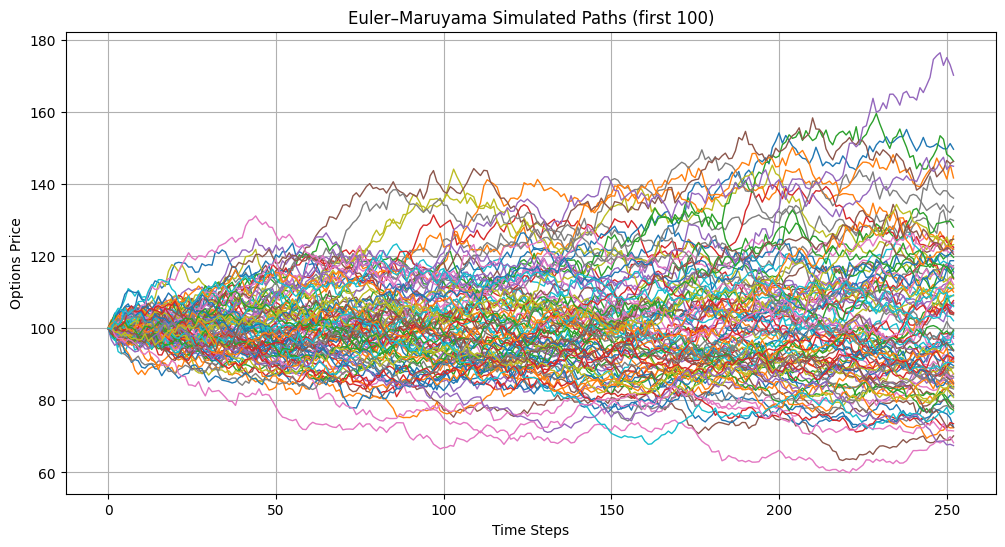

In [ ]:
# visualizing the simulated paths
plt.figure(figsize=(12,6))

# plot only first 100 paths to make the chart readable
for i in range(100):
    plt.plot(paths_em[i, :], lw=1)
plt.title('Euler–Maruyama Simulated Paths (first 100)')
plt.xlabel('Time Steps')
plt.ylabel('Options Price')
plt.grid(True)

In [ ]:
# pricing the European and Binary call and quantify the statistical uncertainty

# extracting simulated options price at maturity and n_paths
S_T = paths_em[:, -1]
N   = S_T.size

# calculating the raw payoffs for each path/ option type
eu_call_payoff = np.maximum(S_T - K, 0.0)
binary_payoff  = (S_T >= K).astype(float)

# calculating the discounted price
disc = np.exp(-r*T)
C_MC = disc * eu_call_payoff.mean()
B_MC = disc * binary_payoff.mean()

# calculating the standard error - use ddof=1 as an unbiased estimator
se_C = disc * eu_call_payoff.std(ddof=1) / np.sqrt(N)
se_B = disc * binary_payoff.std(ddof=1)  / np.sqrt(N)

# calculating the confidence interval (assume CI=95%)
C_lo, C_hi = C_MC - 1.96*se_C, C_MC + 1.96*se_C
B_lo, B_hi = B_MC - 1.96*se_B, B_MC + 1.96*se_B

# calculating errors against black-schles benchmarks
err_C, err_B = C_MC - C_BS, B_MC - B_BS

# putting results into a dataframe
EM_df = pd.DataFrame([
    ['European call','EM',N,n_steps,seed,C_MC,se_C,C_lo,C_hi,C_BS,err_C, err_C/C_BS, (C_lo <= C_BS <= C_hi)],
    ['Binary call','EM',N,n_steps,seed,B_MC,se_B,B_lo,B_hi,B_BS,err_B, err_B/B_BS, (B_lo <= B_BS <= B_hi)],
], columns=[
    'Option', 'Method', 'N_used', 'N_steps', 'Seed', 'Monte_Carlo_Price', 'SE', 'CI_low', 'CI_high',
    'Black_Scholes_Price', 'Absolute_Error', 'Relative_Error', 'Within_CI'
])

print(f'd1 = {d1:.4f}, d2 = {d2:.4f}  |  Seed={seed}, N_used={N:,} (i.e. {n_paths:,} paths)')
EM_df.round(4)

d1 = 0.3500, d2 = 0.1500  |  Seed=42, N_used=50,000 (i.e. 50,000 paths)


,Option,Method,N_used,N_steps,Seed,Monte_Carlo_Price,SE,CI_low,CI_high,Black_Scholes_Price,Absolute_Error,Relative_Error,Within_CI
0,European call,EM,50000,252,42,10.4177,0.0656,10.2892,10.5461,10.4506,-0.0329,-0.0032,True
1,Binary call,EM,50000,252,42,0.5323,0.0021,0.5281,0.5364,0.5323,-0.0001,-0.0001,True


The Euler-Maruyama method, implemented with 50,000 paths, 252 steps, and seed 42, provides the following option pricing results:

- For the European call option, the Monte Carlo price is 10.4177 ± 0.0656 (95% CI: [10.2892, 10.5461]), closely aligning with the Black-Scholes benchmark of 10.4506, with an absolute error of -0.0329 (-0.0032 or 0.32% relative error), and the benchmark falls within the confidence interval.
- For the binary call option, the Monte Carlo price is 0.5323, (95% CI [0.5281, 0.5364]), SE at 0.0021. It matches Black–Scholes 0.5323 (abs. error −0.0001, ≈ −0.01%), the benchmark falls within the confidence interval.

These results demonstrate that the simulation effectively approximates the analytical Black-Scholes prices, with narrow confidence intervals due to the large number of paths, indicating minimal bias.

**<h3>2) Monte Carlo Simulation Under Milstein Method</h3>**

Under the risk-neutral measure Q, the stock price follows a GBM. We simulate paths on a grid t<sub>k</sub> with step Δt and simulate path of S by repeatedly applying the Milstein scheme with Brownian increments ΔW ~ N(0, Δt). This implements pricing by the discounted expectation E<sup>Q</sup>[·]. Formulas we will be using to complete this section of the calculation - </br>

**Milstein Update:**
$$
S_{k+1} = S_k + r S_k \Delta t + \sigma S_k \Delta W_{m,k} + \frac{1}{2} \sigma^2 S_k ((\Delta W_{m,k})^2 - \Delta t)
$$

**Options Payoff at Maturity:**
$$
\text{European call: } \max(S_T - K, 0)
\qquad and \qquad
\text{Binary call: } \mathbf{1}\{ S_T > K \}
$$

**Discounted Payoff:**
$$
Y_m = e^{-rT} \cdot \text{Payoff}^{(m)}
$$

**Monte Carlo Estimator:**
$$
\hat{V} = \frac{1}{M} \sum_{m=1}^M Y_m
$$

**Standard error and confidence interval (CI assumed = 0.95):**
$$
s^2 = \frac{1}{M-1} \sum_{m=1}^M (Y_m - \hat{V})^2,
\quad
SE = \frac{s}{\sqrt{M}},
\quad
95\% \; CI = \hat{V} \pm 1.96 \cdot SE
$$

**The Importance of Common Random Number (CRN):**
</br> In order to generate a like-to-like comparison for Milstein against the Euler-Maruyama method, the same global seed will be re-used in the same ΔW matrix across both schemes. This approach will help to isolate time-step bias vs sampling noise. The approach of discounting once at maturity under risk-neutral measure remains unchanged.


In [ ]:
# Simulating Milstein Path under risk-neutral GBM
# S_{t+Δt} = S_t + r S_t Δt + σ S_t ΔW + 0.5 σ^2 S_t (ΔW^2 - Δt),  ΔW ~ N(0, Δt)

def simulate_milstein_paths(S0, r, sigma, T, n_paths, n_steps, seed=None):

    if seed is not None:
        np.random.seed(seed)  # align starting point of RNG stream to EM's seed

    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)

    paths = np.empty((n_paths, n_steps + 1), dtype=np.float64)
    paths[:, 0] = S0
    S = paths[:, 0].copy()

    for t in range(1, n_steps + 1):
        z  = np.random.standard_normal(n_paths)
        dW = sqrt_dt * z
        S  = S + r*S*dt + sigma*S*dW + 0.5*(sigma**2)*S*(dW*dW - dt)
        paths[:, t] = S

    return paths

In [ ]:
# showing the full path
paths_mi = simulate_milstein_paths(S0=S0, r=r, sigma=sigma, T=T,
                                   n_paths=n_paths, n_steps=n_steps, seed=seed)

paths_mi_df = pd.DataFrame(paths_mi)
print('Note: Column header represents the steps taken on the path')
paths_mi_df.head(2)

Note: Column header represents the steps taken on the path


,0,1,2,3,4,5,6,7,8,9,...,243,244,245,246,247,248,249,250,251,252
0,100.0,100.639664,100.776241,102.105240,103.89482,105.971676,106.727244,104.874295,105.579179,109.706594,...,152.783821,150.417466,150.065294,150.335671,151.010093,150.212635,149.605526,149.538199,151.015624,149.441002
1,100.0,99.837860,99.769140,98.339337,98.21700,98.112162,100.315559,101.022260,100.140667,99.965914,...,85.507893,86.599986,85.389002,85.361517,83.925452,85.133968,86.917019,88.524058,86.565121,84.896663


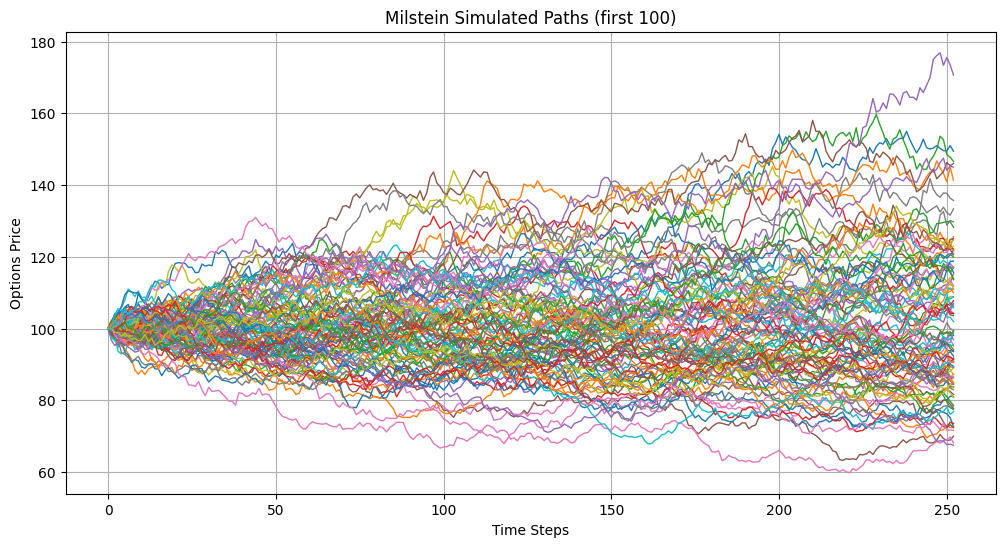

In [ ]:
# visualizing the simulated paths
plt.figure(figsize=(12,6))

# plot only first 100 paths to make the chart readable
for i in range(100):
    plt.plot(paths_mi[i, :], lw=1)
plt.title('Milstein Simulated Paths (first 100)')
plt.xlabel('Time Steps')
plt.ylabel('Options Price')
plt.grid(True)

In [ ]:
# pricing the European and Binary call and quantify the statistical uncertainty

# extracting simulated options price at maturity and n_paths
S_T_mi = paths_mi[:, -1]
N_mi   = S_T_mi.size

# calculating the raw payoffs for each path/ option type
EU_call_payoff_mi = np.maximum(S_T_mi - K, 0.0)
binary_payoff_mi  = (S_T_mi >= K).astype(float)

# calculating the discounted price
disc = np.exp(-r*T)
C_MC_mi = disc * EU_call_payoff_mi.mean()
B_MC_mi = disc * binary_payoff_mi.mean()

# calculating the standard error - use ddof=1 as an unbiased estimator
se_C_mi = disc * EU_call_payoff_mi.std(ddof=1) / np.sqrt(N_mi)
se_B_mi = disc * binary_payoff_mi.std(ddof=1)  / np.sqrt(N_mi)

# calculating the confidence interval (assume CI=95%)
C_lo_mi, C_hi_mi = C_MC_mi - 1.96*se_C_mi, C_MC_mi + 1.96*se_C_mi
B_lo_mi, B_hi_mi = B_MC_mi - 1.96*se_B_mi, B_MC_mi + 1.96*se_B_mi

# calculating errors against black-schles benchmarks
err_C_mi, err_B_mi = C_MC_mi - C_BS, B_MC_mi - B_BS

# putting results into a dataframe
MI_df = pd.DataFrame([
    ["European call","Milstein",N_mi,n_steps,seed,C_MC_mi,se_C_mi,C_lo_mi,C_hi_mi,C_BS,err_C_mi, err_C_mi/C_BS, (C_lo_mi <= C_BS <= C_hi_mi)],
    ["Binary call","Milstein",N_mi,n_steps,seed,B_MC_mi,se_B_mi,B_lo_mi,B_hi_mi,B_BS,err_B_mi, err_B_mi/B_BS, (B_lo_mi <= B_BS <= B_hi_mi)],
], columns=[
    'Option', 'Method', 'N_used', 'N_steps', 'Seed', 'Monte_Carlo_Price', 'SE', 'CI_low', 'CI_high',
    'Black_Scholes_Price', 'Absolute_Error', 'Relative_Error', 'Within_CI'
])

# Side by Side Comparison - EM vs Milstein
results_df = pd.concat([EM_df, MI_df], ignore_index=True)
print(f'd1 = {d1:.4f}, d2 = {d2:.4f}  |  Seed={seed}, N_used={N:,} (i.e. {n_paths:,} paths)')
results_df.round(4)

d1 = 0.3500, d2 = 0.1500  |  Seed=42, N_used=50,000 (i.e. 50,000 paths)


,Option,Method,N_used,N_steps,Seed,Monte_Carlo_Price,SE,CI_low,CI_high,Black_Scholes_Price,Absolute_Error,Relative_Error,Within_CI
0,European call,EM,50000,252,42,10.4177,0.0656,10.2892,10.5461,10.4506,-0.0329,-0.0032,True
1,Binary call,EM,50000,252,42,0.5323,0.0021,0.5281,0.5364,0.5323,-0.0001,-0.0001,True
2,European call,Milstein,50000,252,42,10.4161,0.0656,10.2876,10.5446,10.4506,-0.0345,-0.0033,True
3,Binary call,Milstein,50000,252,42,0.5321,0.0021,0.5280,0.5363,0.5323,-0.0002,-0.0004,True


The Milstein method, under the same parameters, yields:

For the European call option, the Monte Carlo price is 10.4161, SE 0.0656, (95% CI: [10.2876, 10.5446]), with an absolute error of -0.0345 (-0.33% relative error), and the benchmark remains within the confidence interval as Black-Scholes is 10.4506. </br>

For the binary call option, the Monte Carlo price is 0.5321, SE 0.0021, (95% CI: [0.5280, 0.5363]), with an absolute error of -0.0002 (-0.04% relative error), also within the confidence interval as Black-Scholes is 0.5323.
</br>

If we put the results side by side, both schemes produce very similar results, differing by only 0.0016 (0.015%) for the European call and 0.0002 (0.04%) for the binary call—well below the SE of 0.0656 and 0.0021, respectively. Both matches the Black-Scholes benchmark within their confidence interval. </br>

This minimal divergence reflects the use of common random numbers, isolating scheme effects, and confirms that at a daily grid (252 steps), Milstein's higher-order correction offers no practical advantage over EM for pricing or uncertainty estimation. These outcomes validate both methods against the Black-Scholes benchmarks, with tight confidence intervals indicating sufficient paths for reliable approximation and negligible bias.

**<h3>4) Error and Convergence Analysis</h3>**

The Error and Convergence analysis helps to quantify the accuracy and reliability of option pricing under the risk-neutral pricing framework. While the Black-Scholes model can provide estimates, it is a closed-form solution under its assumptions, where real-world application will at times devitate from these assumptions. Therefore, Monte Carlo methods like Euler-Maruyama (EM) and Milstein exists to help simulate risk-neutral GBM and discount payoffs at maturity and express them numerically.

However, there are two sources of error under these numerical approaches:
- **Sampling Error**: Arising from using a finite number of paths (50,000 in our simulation scenario), this introduces noise in the Monte Carlo estimation. The standard error (SE) measures this uncertainty, scaling as $1 / \sqrt{N}$, where \( N \) is the number of paths. We report a 95% confidence interval (CI) as $\hat{V} \pm 1.96 \cdot \text{SE}$ to assess statistical reliability.
- **Time-Step Bias**: Arising from simulating a continuous stochastic differential equation (SDE) on a discrete time grid (252 steps in our simulation scenario), this bias diminishes as the steps increase (as such, step size $\Delta t$ decreases).

Although the current calculated values between EM and Milstein looks to be of negligable differences under the current resolution (252 steps), it is still meaningful to perform an error and convergence analysis as it help validates whether the chosen grid and path counts are sufficient. It also helps to confirm both schemes converge into the Black-Scholes benchmark and further insights into sampling vs time-step discretization error. These insights are useful in practical applications, especially when e.g. coarser grids are used for faster computation time or with introduction with other parameters. It ensures the robustness of the scheme beyond the current setup.

Thus, we will compute SE and 95% CI, compare EM and Milstein against the Black-Scholes closed-form solution, and conduct convergence studies by varying \( N \) and steps to illustrate accuracy, uncertainty, and the trade-offs in numerical precision.

**4.1) Sampling Error Analysis**

In [ ]:
# Sampling error (EM vs Milstein)

# copying fixed time step from previous calcultion & set varying N
steps_fixed = 252
Ns = [1_000, 5_000, 10_000, 50_000, 100_000]

disc = np.exp(-r * T)
rows = []

for N in Ns:
    # ensures different random seed across different N values under EM/ Milstein run
    seed = 42 + N

    # EM runs
    np.random.seed(seed)
    paths_em = simulate_em_paths(S0=S0, r=r, sigma=sigma, T=T, n_paths=N, n_steps=steps_fixed)
    ST = paths_em[:, -1]
    EU_call_payoff   = np.maximum(ST - K, 0.0)
    binary_payoff    = (ST > K).astype(float)
    C_em  = disc * EU_call_payoff.mean()
    B_em  = disc * binary_payoff.mean()
    Cse_em = disc * EU_call_payoff.std(ddof=1) / np.sqrt(N)
    Bse_em = disc * binary_payoff.std(ddof=1)  / np.sqrt(N)
    rows.append(['EM', N, steps_fixed, C_em, Cse_em, abs(C_em - C_BS), 2*1.96*Cse_em,
                                  B_em, Bse_em, abs(B_em - B_BS), 2*1.96*Bse_em])

    # Milstein runs
    paths_mi = simulate_milstein_paths(S0=S0, r=r, sigma=sigma, T=T,
                                       n_paths=N, n_steps=steps_fixed, seed=seed)
    ST = paths_mi[:, -1]
    EU_call_payoff   = np.maximum(ST - K, 0.0)
    binary_payoff    = (ST > K).astype(float)
    C_mi  = disc * EU_call_payoff.mean()
    B_mi  = disc * binary_payoff.mean()
    Cse_mi = disc * EU_call_payoff.std(ddof=1) / np.sqrt(N)
    Bse_mi = disc * binary_payoff.std(ddof=1)  / np.sqrt(N)
    rows.append(['Milstein', N, steps_fixed, C_mi, Cse_mi, abs(C_mi - C_BS), 2*1.96*Cse_mi,
                                   B_mi, Bse_mi, abs(B_mi - B_BS), 2*1.96*Bse_mi])

# side-by-side results in dataframe
sampling_df = pd.DataFrame(rows, columns=[
    'Method', 'N', 'Fixed_Steps', 'EU_Call_Price', 'EU_Call_SE', 'EU_Call_Abs_Error',
    'EU_Call_Width_CI_95', 'Binary_Call_Price', 'Binary_SE', 'Binary_Abs_Error', 'Binary_Width_CI_95']).sort_values(['Method', 'N']).reset_index(drop=True)

sampling_df.round(4)

,Method,N,Fixed_Steps,EU_Call_Price,EU_Call_SE,EU_Call_Abs_Error,EU_Call_Width_CI_95,Binary_Call_Price,Binary_SE,Binary_Abs_Error,Binary_Width_CI_95
0,EM,1000,252,10.4115,0.4588,0.0390,1.7987,0.5546,0.0148,0.0222,0.0582
1,EM,5000,252,10.6864,0.2142,0.2359,0.8397,0.5302,0.0067,0.0021,0.0262
2,EM,10000,252,10.5926,0.1503,0.1421,0.5893,0.5307,0.0047,0.0016,0.0185
3,EM,50000,252,10.4020,0.0657,0.0486,0.2574,0.5319,0.0021,0.0004,0.0083
4,EM,100000,252,10.4423,0.0465,0.0083,0.1824,0.5333,0.0015,0.0010,0.0059
5,Milstein,1000,252,10.4079,0.4589,0.0427,1.7990,0.5555,0.0148,0.0232,0.0581
6,Milstein,5000,252,10.6880,0.2143,0.2374,0.8400,0.5302,0.0067,0.0021,0.0262
7,Milstein,10000,252,10.5940,0.1504,0.1434,0.5896,0.5305,0.0047,0.0018,0.0185
8,Milstein,50000,252,10.4010,0.0657,0.0495,0.2575,0.5319,0.0021,0.0005,0.0083
9,Milstein,100000,252,10.4408,0.0466,0.0098,0.1825,0.5333,0.0015,0.0009,0.0059


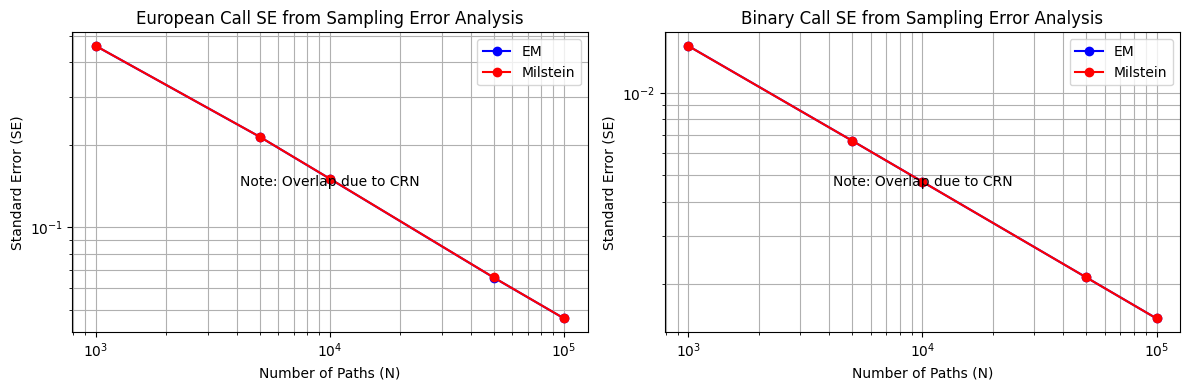

In [ ]:
# Plotting SE vs N (log-log scale) for EM and Milstein

# Filter data
em_data = sampling_df[sampling_df['Method'] == 'EM']
mi_data = sampling_df[sampling_df['Method'] == 'Milstein']

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Subplot 1: European Call SE
ax1.loglog(em_data['N'], em_data['EU_Call_SE'], 'b-o', label='EM')
ax1.loglog(mi_data['N'], mi_data['EU_Call_SE'], 'r-o', label='Milstein')
ax1.set_title('European Call SE from Sampling Error Analysis')
ax1.set_xlabel('Number of Paths (N)')
ax1.set_ylabel('Standard Error (SE)')
ax1.legend()
ax1.grid(True, which='both')
ax1.text(0.5, 0.5, 'Note: Overlap due to CRN', transform=ax1.transAxes,
         ha='center', va='center')

# Subplot 2: Binary Call SE
ax2.loglog(em_data['N'], em_data['Binary_SE'], 'b-o', label='EM')
ax2.loglog(mi_data['N'], mi_data['Binary_SE'], 'r-o', label='Milstein')
ax2.set_title('Binary Call SE from Sampling Error Analysis')
ax2.set_xlabel('Number of Paths (N)')
ax2.set_ylabel('Standard Error (SE)')
ax2.legend()
ax2.grid(True, which='both')
ax2.text(0.5, 0.5, 'Note: Overlap due to CRN', transform=ax2.transAxes,
         ha='center', va='center')

plt.tight_layout()
plt.show()

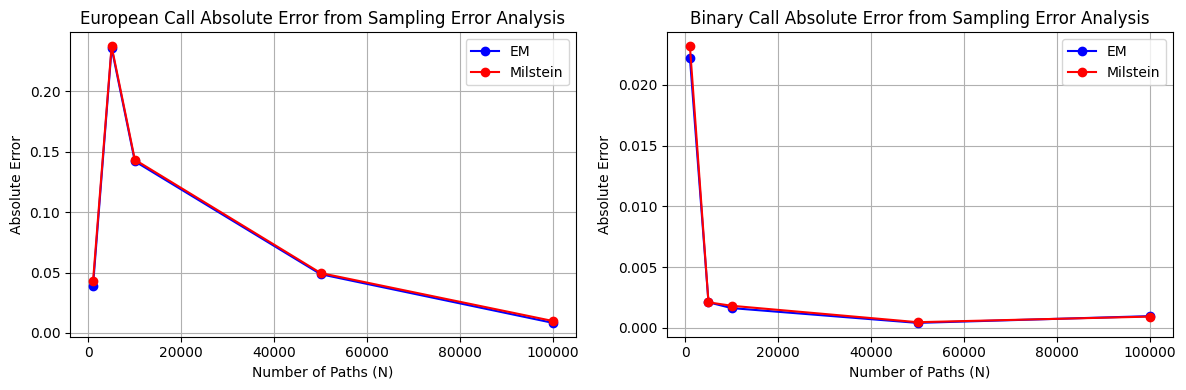

In [ ]:
# Plotting Absolute Error vs N for EM and Milstein

# Filter data
em_data = sampling_df[sampling_df['Method'] == 'EM']
mi_data = sampling_df[sampling_df['Method'] == 'Milstein']

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Subplot 1: European Call Absolute Error
ax1.plot(em_data['N'], em_data['EU_Call_Abs_Error'], 'b-o', label='EM')
ax1.plot(mi_data['N'], mi_data['EU_Call_Abs_Error'], 'r-o', label='Milstein')
ax1.set_title('European Call Absolute Error from Sampling Error Analysis')
ax1.set_xlabel('Number of Paths (N)')
ax1.set_ylabel('Absolute Error')
ax1.legend()
ax1.grid(True)

# Subplot 2: Binary Call Absolute Error
ax2.plot(em_data['N'], em_data['Binary_Abs_Error'], 'b-o', label='EM')
ax2.plot(mi_data['N'], mi_data['Binary_Abs_Error'], 'r-o', label='Milstein')
ax2.set_title('Binary Call Absolute Error from Sampling Error Analysis')
ax2.set_xlabel('Number of Paths (N)')
ax2.set_ylabel('Absolute Error')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

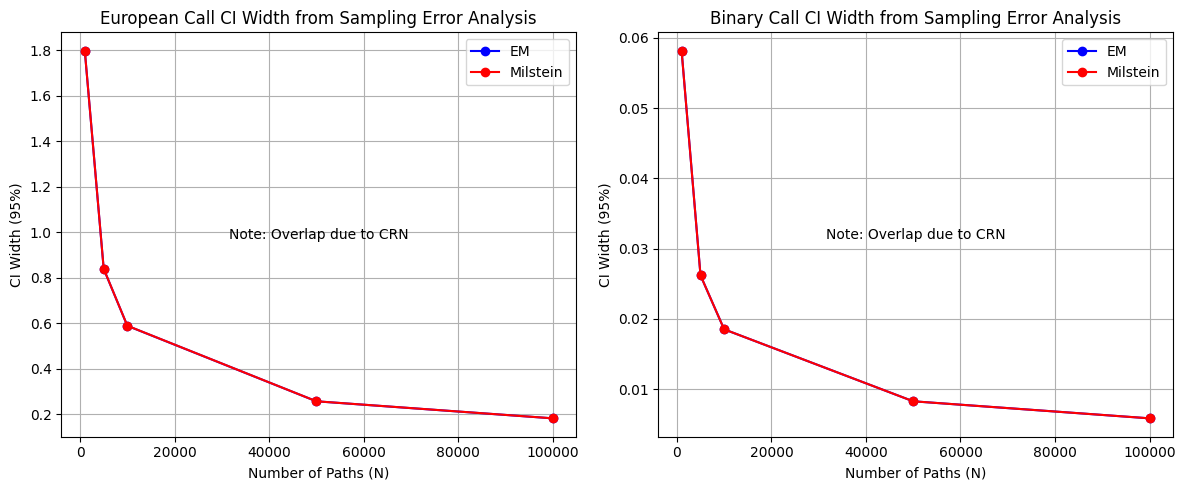

In [ ]:
# Plotting CI Width vs N for EM and Milstein

# Filter data
em_data = sampling_df[sampling_df['Method'] == 'EM']
mi_data = sampling_df[sampling_df['Method'] == 'Milstein']

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# Subplot 1: European Call CI Width
ax1.plot(em_data['N'], em_data['EU_Call_Width_CI_95'], 'b-o', label='EM')
ax1.plot(mi_data['N'], mi_data['EU_Call_Width_CI_95'], 'r-o', label='Milstein')
ax1.set_title('European Call CI Width from Sampling Error Analysis')
ax1.set_xlabel('Number of Paths (N)')
ax1.set_ylabel('CI Width (95%)')
ax1.legend()
ax1.grid(True)
ax1.text(0.5, 0.5, 'Note: Overlap due to CRN', transform=ax1.transAxes,
         ha='center', va='center')

# Subplot 2: Binary Call CI Width
ax2.plot(em_data['N'], em_data['Binary_Width_CI_95'], 'b-o', label='EM')
ax2.plot(mi_data['N'], mi_data['Binary_Width_CI_95'], 'r-o', label='Milstein')
ax2.set_title('Binary Call CI Width from Sampling Error Analysis')
ax2.set_xlabel('Number of Paths (N)')
ax2.set_ylabel('CI Width (95%)')
ax2.legend()
ax2.grid(True)
ax2.text(0.5, 0.5, 'Note: Overlap due to CRN', transform=ax2.transAxes,
         ha='center', va='center')

# Adjust layout
plt.tight_layout()
plt.show()

Insights Observed </br>

As N increases, standard error decreases whether it is in the European call option vs the Binary call option. The Absolute Error also shrinks under both cases (convergence to Black-Scholes). Full width of the confidence interval continues to narrow. </br>

By using the same seed and fixed time steps for each N under EM and Milstein, we ensure there is a consistent time grid, aligning the standard error (SE) and confidence interval (CI) width between methods. This isolates the impact of random noise, allowing any differences in price or absolute error to directly reflect the discretization bias rather than the sampling variability.</br>

From the 95% CI plot chart, it can also be observed that CI width narrows with increasing \( N \), which proves that sampling error reduces as N increases.

**4.2) Time-Step Bias Analysis**

In [ ]:
# Time-step bias vs Steps (EM vs Milstein)

# copying fixed N from previous calcultion & set varying time step grid
N_fixed    = 50_000
steps_grid = [16, 32, 64, 128, 252, 512]

disc = np.exp(-r * T)
rows = []

for steps in steps_grid:
    # ensures different random seed across different step values under EM/ Milstein run
    seed_steps = seed + steps

    # EM run
    np.random.seed(seed_steps)
    paths_em = simulate_em_paths(S0=S0, r=r, sigma=sigma, T=T, n_paths=N_fixed, n_steps=steps)
    ST = paths_em[:, -1]
    call_pay = np.maximum(ST - K, 0.0)
    bin_pay  = (ST > K).astype(float)
    C_em  = disc * call_pay.mean()
    B_em  = disc * bin_pay.mean()
    Cse_em = disc * call_pay.std(ddof=1) / np.sqrt(N_fixed)
    Bse_em = disc * bin_pay .std(ddof=1) / np.sqrt(N_fixed)
    rows.append(['EM', N_fixed, steps, C_em, abs(C_em - C_BS), Cse_em,
                             B_em, abs(B_em - B_BS), Bse_em])

    # Milstein run
    paths_mi = simulate_milstein_paths(S0=S0, r=r, sigma=sigma, T=T,
                                       n_paths=N_fixed, n_steps=steps, seed=seed_steps)
    ST = paths_mi[:, -1]
    call_pay = np.maximum(ST - K, 0.0)
    bin_pay  = (ST > K).astype(float)
    C_mi  = disc * call_pay.mean()
    B_mi  = disc * bin_pay.mean()
    Cse_mi = disc * call_pay.std(ddof=1) / np.sqrt(N_fixed)
    Bse_mi = disc * bin_pay .std(ddof=1) / np.sqrt(N_fixed)
    rows.append(['Milstein', N_fixed, steps, C_mi, abs(C_mi - C_BS), Cse_mi,
                               B_mi, abs(B_mi - B_BS), Bse_mi])

# side-by-side results in dataframe
steps_df = pd.DataFrame(rows, columns=[
    'Method', 'Fixed_N', 'Steps', 'EU_Call_Price', 'EU_Call_Abs_Error', 'EU_Call_SE',
    'Binary_Call_Price', 'Binary_Abs_Error', 'Binary_SE']).sort_values(['Method', 'Steps']).reset_index(drop=True)

steps_df.round(4)

,Method,Fixed_N,Steps,EU_Call_Price,EU_Call_Abs_Error,EU_Call_SE,Binary_Call_Price,Binary_Abs_Error,Binary_SE
0,EM,50000,16,10.4252,0.0254,0.0655,0.5322,0.0001,0.0021
1,EM,50000,32,10.4293,0.0213,0.0654,0.5351,0.0028,0.0021
2,EM,50000,64,10.4807,0.0301,0.0656,0.5330,0.0007,0.0021
3,EM,50000,128,10.4052,0.0453,0.0656,0.5320,0.0003,0.0021
4,EM,50000,252,10.3899,0.0607,0.0658,0.5327,0.0003,0.0021
5,EM,50000,512,10.4485,0.0021,0.0659,0.5321,0.0002,0.0021
6,Milstein,50000,16,10.4078,0.0428,0.0660,0.5301,0.0023,0.0021
7,Milstein,50000,32,10.4229,0.0277,0.0656,0.5344,0.0021,0.0021
8,Milstein,50000,64,10.4768,0.0262,0.0657,0.5325,0.0002,0.0021
9,Milstein,50000,128,10.4038,0.0468,0.0656,0.5317,0.0006,0.0021


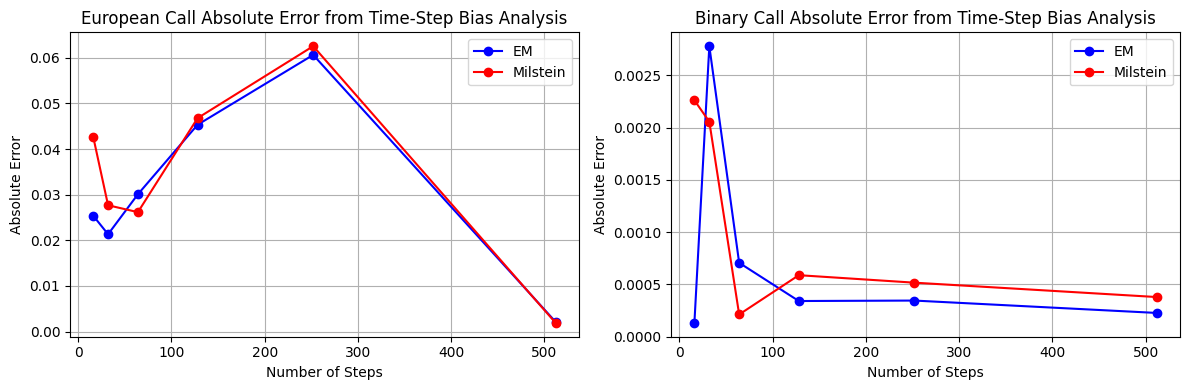

In [ ]:
# Plotting Absolute Error vs Steps for EM and Milstein

# Filter data
em_data = steps_df[steps_df['Method'] == 'EM']
mi_data = steps_df[steps_df['Method'] == 'Milstein']

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Subplot 1: European Call Absolute Error
ax1.plot(em_data['Steps'], em_data['EU_Call_Abs_Error'], 'b-o', label='EM')
ax1.plot(mi_data['Steps'], mi_data['EU_Call_Abs_Error'], 'r-o', label='Milstein')
ax1.set_title('European Call Absolute Error from Time-Step Bias Analysis')
ax1.set_xlabel('Number of Steps')
ax1.set_ylabel('Absolute Error')
ax1.legend()
ax1.grid(True)

# Subplot 2: Binary Call Absolute Error
ax2.plot(em_data['Steps'], em_data['Binary_Abs_Error'], 'b-o', label='EM')
ax2.plot(mi_data['Steps'], mi_data['Binary_Abs_Error'], 'r-o', label='Milstein')
ax2.set_title('Binary Call Absolute Error from Time-Step Bias Analysis')
ax2.set_xlabel('Number of Steps')
ax2.set_ylabel('Absolute Error')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

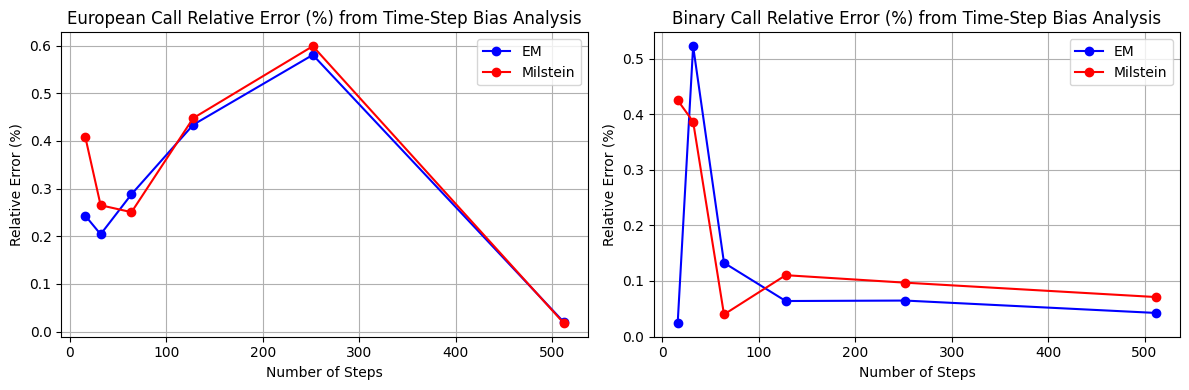

In [ ]:
# Plotting Relative Error vs Steps for EM and Milstein

# Calculate relative errors
em_data = steps_df[steps_df['Method'] == 'EM'].copy()
mi_data = steps_df[steps_df['Method'] == 'Milstein'].copy()
em_data['EU_Rel_Error'] = em_data['EU_Call_Abs_Error'] / C_BS * 100
em_data['Binary_Rel_Error'] = em_data['Binary_Abs_Error'] / B_BS * 100
mi_data['EU_Rel_Error'] = mi_data['EU_Call_Abs_Error'] / C_BS * 100
mi_data['Binary_Rel_Error'] = mi_data['Binary_Abs_Error'] / B_BS * 100

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Subplot 1: European Call Relative Error
ax1.plot(em_data['Steps'], em_data['EU_Rel_Error'], 'b-o', label='EM')
ax1.plot(mi_data['Steps'], mi_data['EU_Rel_Error'], 'r-o', label='Milstein')
ax1.set_title('European Call Relative Error (%) from Time-Step Bias Analysis')
ax1.set_xlabel('Number of Steps')
ax1.set_ylabel('Relative Error (%)')
ax1.legend()
ax1.grid(True)

# Subplot 2: Binary Call Relative Error
ax2.plot(em_data['Steps'], em_data['Binary_Rel_Error'], 'b-o', label='EM')
ax2.plot(mi_data['Steps'], mi_data['Binary_Rel_Error'], 'r-o', label='Milstein')
ax2.set_title('Binary Call Relative Error (%) from Time-Step Bias Analysis')
ax2.set_xlabel('Number of Steps')
ax2.set_ylabel('Relative Error (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Insights Observed </br>

As steps increases, standard error remains relatively stable whether it is in the European call option vs the Binary call option due to fixed N. The Absolute Error also shrinks under both cases (convergence to Black-Scholes) with finer time steps. </br>

By using the same seed and fixed number of paths for each step under EM and Milstein, we ensure there is a consistent random sequence, aligning the standard error (SE) between methods. This isolates the impact of random noise, allowing any differences in price or absolute error to directly reflect the discretization bias rather than the sampling variability.</br>

From the Absolute Error plot chart, it can also be observed that absolute error narrows with increasing steps, which proves that discretization bias reduces as steps increases and step size (Delta t) decreases. </br>

It's worth noting that in both plots for Absolute or Relative Error, the EM behavior looks unusual with very low error at 16 steps, and with error peaked at 32 steps, gradually decreasing that after. This is a known behavior for EM in coarser steps, also with binary options, the payoff is all or nothing structure hence the overall picture looks a lot noisier, leading to irregular convergence. However as time steps does increase, it eventually still converges with Black-Scholes baseline.


<p><strong>Paths vs steps: what reduces uncertainty fastest</strong><br>
Holding steps at 252 and increasing <em>N</em>, the 95% CI width shrinks roughly like <em>1/√N</em>, so sampling drives uncertainty. At 50k paths, the call’s gap to Black–Scholes is about <strong>0.033</strong>, which is small compared with the ±<strong>0.129</strong> band; adding <em>paths</em> tightens results more effectively than refining the grid. When we refine steps (e.g., 16 → 512), the difference to Black–Scholes decreases quickly at first and then flattens beyond daily grids; by ~<strong>512</strong> steps the remaining grid effect is tiny. (In our step table, EM’s |price−BS| moved from about <strong>0.0655</strong> at 16 steps to about <strong>0.0021</strong> at 512 steps.)</p>

<p><strong>Binary payoff sensitivity and EM/Milstein comparison</strong><br>
Because the binary payoff jumps at the strike, its estimate is more sensitive at low <em>N</em> and on very coarse grids; confidence intervals are naturally wider than for the smooth European call. In our step sweep we saw small irregularities for EM at low step counts (e.g., a dip at 16 followed by a bump at 32) that disappear as steps increase. Milstein looked slightly steadier on coarse grids, but at daily steps both schemes are statistically indistinguishable.</p>

<p><strong>Other practical considerations</strong><br>
We used a fixed seed with <em>common random numbers</em> across EM and Milstein so differences reflect the scheme, not luck in the draws. Runtime-wise, once the grid is sensible (≈252–512 steps), the highest return on compute is to increase <em>N</em>. Choose steps to be reasonable, then spend the budget on paths to shrink the CI.</p>


**<h3>6) Conclusion</h3>**

Our analysis confirms that both Euler–Maruyama and Milstein methods correctly priced the European and Binary call options, and aligns with Black-Scholes benchmarks within 95% CI when using a reasonable daily grid (252 steps). The small gaps (e.g., 0.033 for call at 252 steps) are minimal by sampling uncertainty (±0.129), highlighting that path count drives precision more than step refinements. This insight holds across varying N and steps, with sampling error dominating at fine grids and discretization bias becoming negligible beyond daily steps.

EM and Milstein show similar performance at 252 steps, but EM exhibits irregular convergence at coarser steps (e.g., Binary error peaking at 0.0028 at 32 steps), reflecting its sensitivity to discontinuous payoffs. Milstein offers steadier bias reduction (e.g., 0.0023 at 16 steps), suggesting an advantage for coarser grids. The Binary call’s all-or-nothing structure amplifies this noise, necessitating higher path counts for stability.

**Recommendations:**
- **Scheme:** Use EM for simplicity at daily steps, switch to Milstein for needing to work with coarser grids but wanting better accuracy.
- **Steps:** 252 is quite optimal, as results are suggesting extending to 512 only to have negligible upside gains.
- **Paths:** 50k is a good ballpark number to consider in both European alls and Binary options scenario based on results calculated. However, if the type of option and payoff structure changes, this may need to be re-considered

This approach validates the risk-neutral framework numerically, with CRN and large N ensuring reliability, though varying seeds across steps limit smooth bias tracking. If even tighter confidence intervals are required, consider further increasing N (paths), instead of steps.

**<h3>7) References </h3>**

- **Module 3 notes/exercises/solutions:**
  - JU253.1 Notes, Black–Scholes pricing
  - JU253.2 “Stock Price & Discounted Stock Price”
  - JU253.2 “Changing Probability Measure”
  - JU253.2 “Martingale Theory – Pricing Options 2025_updated”
  - JU253.3 Notes - numerical methods overview and links between Black-Scholes/trees/Monte Carlo
- **Python labs:** 8.blackscholes.ipynb, 9.montecarlo.ipynb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install nbconvert==7.* jupyterlab_pygments
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/CQF/CQF Exam 2.ipynb" --output "/content/drive/MyDrive/Colab Notebooks/CQF/CQF Exam 2.html"

Mounted at /content/drive
[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/CQF/CQF Exam 2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 2303933 bytes to /content/drive/MyDrive/Colab Notebooks/CQF/CQF Exam 2.html
